In [76]:
import numpy as np
import pandas as pd
import unicodedata

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB

from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

In [77]:
SMELLS =  ["God Class", "Feature Envy", "Long Method"]
KEY = ["clean_code", "smell", "username"]
FULL_KEY = KEY + ["dup_id"]
NUM_CLASSES = len(SMELLS)

In [78]:
def normalize_colname(c: str) -> str:
    s = unicodedata.normalize("NFKC", str(c))
    s = s.replace("\u200b", "").replace("\ufeff", "")
    return s.strip().lower()

def valid_embedding(v):
    return isinstance(v, (list, tuple, np.ndarray)) and len(v) > 0

def load_prepared_with_dupid(path, smells=SMELLS):
    df = pd.read_pickle(path).copy()

    df = df.rename(columns={c: normalize_colname(c) for c in df.columns})

    missing = set(KEY + ["embedding"]) - set(df.columns)
    if missing:
        raise ValueError(
            f"En {path} faltan columnas: {missing}. Columnas actuales: {df.columns.tolist()}"
        )

    df["smell"] = df["smell"].astype(str).str.strip().str.lower()
    df["username"] = df["username"].astype(str).str.strip().str.lower()
    df["clean_code"] = df["clean_code"].astype(str)

    df = df[df["smell"].isin([s.lower() for s in smells])].copy()

    df = df.dropna(subset=KEY + ["embedding"])
    df = df[df["embedding"].apply(valid_embedding)].copy()

    df["dup_id"] = df.groupby(KEY).cumcount()

    return df[FULL_KEY + ["embedding"]].reset_index(drop=True)

In [79]:
def build_merged_with_dupid(path_openai, path_codebert):
    oa = load_prepared_with_dupid(path_openai)
    cb = load_prepared_with_dupid(path_codebert)

    print("OpenAI filas:", len(oa))
    print("CodeBERT filas:", len(cb))
    print("Duplicados OpenAI por KEY (sin dup_id):", oa.duplicated(subset=KEY).sum())
    print("Duplicados CodeBERT por KEY (sin dup_id):", cb.duplicated(subset=KEY).sum())

    print("Duplicados OpenAI por FULL_KEY:", oa.duplicated(subset=FULL_KEY).sum())
    print("Duplicados CodeBERT por FULL_KEY:", cb.duplicated(subset=FULL_KEY).sum())

    merged = oa.merge(
        cb,
        on=FULL_KEY,
        how="inner",
        suffixes=("_openai", "_codebert"),
        validate="one_to_one"
    )

    print("\nMerged filas (inner, one_to_one con dup_id):", len(merged))
    print("\nDistribución de clases en merged:")
    print(merged["smell"].value_counts())

    return merged

In [80]:
def group_split_indices(merged, test_size=0.2, random_state=42):
    idx = np.arange(len(merged))
    groups = merged["clean_code"].to_numpy()

    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(idx, groups=groups))

    train_codes = set(merged.iloc[train_idx]["clean_code"])
    test_codes = set(merged.iloc[test_idx]["clean_code"])

    print("\n=== Split por clean_code (GroupShuffleSplit) ===")
    print("Filas train:", len(train_idx), "Filas test:", len(test_idx))
    print("Códigos únicos train:", len(train_codes), "Códigos únicos test:", len(test_codes))
    print("Overlap clean_code (debe ser 0):", len(train_codes & test_codes))

    print("\nClases train:")
    print(merged.iloc[train_idx]["smell"].value_counts())
    print("\nClases test:")
    print(merged.iloc[test_idx]["smell"].value_counts())

    return train_idx, test_idx

In [81]:
def eval_with_split(merged, emb_col, train_idx, test_idx):
    X = np.vstack(merged[emb_col].apply(lambda v: np.asarray(v, dtype=float)).to_numpy())

    le = LabelEncoder()
    y = le.fit_transform(merged["smell"])

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    y_proba = model.predict_proba(X_test)

    report_dict = classification_report(
        y_test,
        y_pred,
        target_names=le.classes_,
        zero_division=0,
        output_dict=True
    )

    metrics_per_smell = (
        pd.DataFrame(report_dict)
        .T
        .reset_index()
        .rename(columns={"index": "smell"})
    )

    metrics_per_smell = metrics_per_smell[
        metrics_per_smell["smell"].isin(le.classes_)
    ].copy()

    metrics_per_smell = metrics_per_smell.rename(columns={
        "precision": "precision",
        "recall": "recall",
        "f1-score": "f1",
        "support": "support"
    })

    metrics_per_smell = metrics_per_smell[
        ["smell", "precision", "recall", "f1", "support"]
    ]

    n_classes = len(le.classes_)
    y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

    roc_auc_ovr_macro = None
    roc_auc_ovr_weighted = None
    roc_auc_ovo_macro = None

    try:
        roc_auc_ovr_macro = roc_auc_score(
            y_test_bin, y_proba, multi_class="ovr", average="macro"
        )
    except Exception:
        pass

    try:
        roc_auc_ovr_weighted = roc_auc_score(
            y_test_bin, y_proba, multi_class="ovr", average="weighted"
        )
    except Exception:
        pass

    try:
        roc_auc_ovo_macro = roc_auc_score(
            y_test_bin, y_proba, multi_class="ovo", average="macro"
        )
    except Exception:
        pass

    roc_auc_per_smell = []
    for i, smell_name in enumerate(le.classes_):
        y_true_i = y_test_bin[:, i]
        y_score_i = y_proba[:, i]

        if len(np.unique(y_true_i)) < 2:
            auc_i = np.nan
        else:
            auc_i = roc_auc_score(y_true_i, y_score_i)

        roc_auc_per_smell.append({
            "smell": smell_name,
            "roc_auc_ovr": auc_i
        })

    roc_auc_per_smell = pd.DataFrame(roc_auc_per_smell)

    metrics_per_smell = metrics_per_smell.merge(
        roc_auc_per_smell,
        on="smell",
        how="left"
    )

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "f1_micro": f1_score(y_test, y_pred, average="micro"),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted"),
        "report": classification_report(
            y_test, y_pred, target_names=le.classes_, zero_division=0
        ),
        "report_dict": report_dict,
        "metrics_per_smell": metrics_per_smell.sort_values("f1", ascending=False),
        "roc_auc_ovr_macro": roc_auc_ovr_macro,
        "roc_auc_ovr_weighted": roc_auc_ovr_weighted,
        "roc_auc_ovo_macro": roc_auc_ovo_macro,
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "classes": list(le.classes_),
        "model": model,
        "y_test": y_test,
        "y_pred": y_pred,
        "y_proba": y_proba
    }

In [82]:
path_openai = "dataset_smells_embeddings_openai.pkl"
path_codebert = "dataset_smells_embeddings_codebert.pkl"

merged = build_merged_with_dupid(path_openai, path_codebert)
train_idx, test_idx = group_split_indices(merged, test_size=0.2, random_state=42)



OpenAI filas: 911
CodeBERT filas: 911
Duplicados OpenAI por KEY (sin dup_id): 7
Duplicados CodeBERT por KEY (sin dup_id): 7
Duplicados OpenAI por FULL_KEY: 0
Duplicados CodeBERT por FULL_KEY: 0

Merged filas (inner, one_to_one con dup_id): 911

Distribución de clases en merged:
smell
long method     554
feature envy    191
god class       166
Name: count, dtype: int64

=== Split por clean_code (GroupShuffleSplit) ===
Filas train: 789 Filas test: 122
Códigos únicos train: 60 Códigos únicos test: 15
Overlap clean_code (debe ser 0): 0

Clases train:
smell
long method     488
god class       165
feature envy    136
Name: count, dtype: int64

Clases test:
smell
long method     66
feature envy    55
god class        1
Name: count, dtype: int64


In [83]:
print(merged.columns.tolist())

['clean_code', 'smell', 'username', 'dup_id', 'embedding_openai', 'embedding_codebert']


In [84]:
required_cols = ["clean_code", "smell", "embedding_openai", "embedding_codebert"]
missing = [c for c in required_cols if c not in merged.columns]
if missing:
    raise ValueError(f"Faltan columnas en merged: {missing}")

merged_cmp = merged.copy()
merged_cmp["clean_code"] = merged_cmp["clean_code"].astype(str)
merged_cmp["smell"] = merged_cmp["smell"].astype(str)
merged_cmp = merged_cmp[merged_cmp["clean_code"].str.strip() != ""].copy()

def valid_embedding(v):
    return isinstance(v, (list, tuple, np.ndarray)) and len(v) > 0

mask_valid = (
    merged_cmp["embedding_openai"].apply(valid_embedding) &
    merged_cmp["embedding_codebert"].apply(valid_embedding)
)

merged_cmp = merged_cmp[mask_valid].reset_index(drop=True)

print("Shape merged_cmp:", merged_cmp.shape)
print("\nDistribución de clases:")
print(merged_cmp["smell"].value_counts())

Shape merged_cmp: (911, 6)

Distribución de clases:
smell
long method     554
feature envy    191
god class       166
Name: count, dtype: int64


In [85]:
RANDOM_STATE = 42
N_SPLITS = 5

le = LabelEncoder()
y = le.fit_transform(merged_cmp["smell"].to_numpy())
class_names = list(le.classes_)
n_classes = len(class_names)

groups = merged_cmp["clean_code"].to_numpy()
texts = merged_cmp["clean_code"].astype(str).to_numpy()

X_openai = np.vstack(
    merged_cmp["embedding_openai"].apply(lambda v: np.asarray(v, dtype=float)).to_numpy()
)

X_codebert = np.vstack(
    merged_cmp["embedding_codebert"].apply(lambda v: np.asarray(v, dtype=float)).to_numpy()
)

print("Clases:", class_names)
print("OpenAI:", X_openai.shape)
print("CodeBERT:", X_codebert.shape)
print("TF-IDF textos:", len(texts))

Clases: ['feature envy', 'god class', 'long method']
OpenAI: (911, 1536)
CodeBERT: (911, 768)
TF-IDF textos: 911


In [86]:
def build_tfidf_vectorizer():
    return TfidfVectorizer(
        lowercase=False,
        token_pattern=r"(?u)\b\w+\b",
        ngram_range=(1, 2),
        max_features=20000
    )

In [87]:
def eval_embeddings_with_stratified_group_kfold(
    X,
    y,
    groups,
    model_builder,
    n_splits=5,
    random_state=42
):
    cv = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    fold_rows = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = model_builder()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)

        roc_auc_ovr_macro = np.nan
        roc_auc_ovr_weighted = np.nan
        roc_auc_ovo_macro = np.nan

        try:
            roc_auc_ovr_macro = roc_auc_score(
                y_test, y_proba, multi_class="ovr", average="macro"
            )
        except Exception:
            pass

        try:
            roc_auc_ovr_weighted = roc_auc_score(
                y_test, y_proba, multi_class="ovr", average="weighted"
            )
        except Exception:
            pass

        try:
            roc_auc_ovo_macro = roc_auc_score(
                y_test, y_proba, multi_class="ovo", average="macro"
            )
        except Exception:
            pass

        fold_rows.append({
            "fold": fold,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "accuracy": accuracy_score(y_test, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_micro": f1_score(y_test, y_pred, average="micro", zero_division=0),
            "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "mcc": matthews_corrcoef(y_test, y_pred),
            "roc_auc_ovr_macro": roc_auc_ovr_macro,
            "roc_auc_ovr_weighted": roc_auc_ovr_weighted,
            "roc_auc_ovo_macro": roc_auc_ovo_macro,
        })

    fold_metrics = pd.DataFrame(fold_rows)
    return fold_metrics

In [88]:
def eval_tfidf_with_stratified_group_kfold(
    texts,
    y,
    groups,
    model_builder,
    n_splits=5,
    random_state=42
):
    cv = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    fold_rows = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(texts, y, groups=groups), start=1):
        X_train_text = texts[train_idx]
        X_test_text = texts[test_idx]
        y_train = y[train_idx]
        y_test = y[test_idx]

        vectorizer = build_tfidf_vectorizer()
        X_train = vectorizer.fit_transform(X_train_text)
        X_test = vectorizer.transform(X_test_text)

        model = model_builder()


        if isinstance(model, GaussianNB):
            X_train_fit = X_train.toarray()
            X_test_fit = X_test.toarray()
        else:
            X_train_fit = X_train
            X_test_fit = X_test

        model.fit(X_train_fit, y_train)
        y_pred = model.predict(X_test_fit)
        y_proba = model.predict_proba(X_test_fit)

        roc_auc_ovr_macro = np.nan
        roc_auc_ovr_weighted = np.nan
        roc_auc_ovo_macro = np.nan

        try:
            roc_auc_ovr_macro = roc_auc_score(
                y_test, y_proba, multi_class="ovr", average="macro"
            )
        except Exception:
            pass

        try:
            roc_auc_ovr_weighted = roc_auc_score(
                y_test, y_proba, multi_class="ovr", average="weighted"
            )
        except Exception:
            pass

        try:
            roc_auc_ovo_macro = roc_auc_score(
                y_test, y_proba, multi_class="ovo", average="macro"
            )
        except Exception:
            pass

        fold_rows.append({
            "fold": fold,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "accuracy": accuracy_score(y_test, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_micro": f1_score(y_test, y_pred, average="micro", zero_division=0),
            "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "mcc": matthews_corrcoef(y_test, y_pred),
            "roc_auc_ovr_macro": roc_auc_ovr_macro,
            "roc_auc_ovr_weighted": roc_auc_ovr_weighted,
            "roc_auc_ovo_macro": roc_auc_ovo_macro,
        })

    fold_metrics = pd.DataFrame(fold_rows)
    return fold_metrics

In [89]:
# Modelos para embeddings
def build_lr_embedding():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])

def build_dt_embedding():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"))
    ])

def build_nb_embedding():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GaussianNB())
    ])

def build_svm_embedding():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_STATE
        ))
    ])

def build_xgb_embedding():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="multi:softprob",
            num_class=NUM_CLASSES,
            eval_metric="mlogloss",
            random_state=RANDOM_STATE
        ))
    ])

In [90]:
# Modelos para TF-IDF
def build_lr_tfidf():
    return LogisticRegression(
        max_iter=4000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )

def build_dt_tfidf():
    return DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        #max_depth=10
        min_samples_leaf=5
    )

def build_nb_tfidf():
    return MultinomialNB()

def build_svm_tfidf():
    return SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True,
        random_state=RANDOM_STATE
    )

def build_xgb_tfidf():
    return XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=NUM_CLASSES,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE
    )

In [91]:
# OpenAI
openai_lr_folds = eval_embeddings_with_stratified_group_kfold(
    X_openai, y, groups, build_lr_embedding, n_splits=N_SPLITS, random_state=RANDOM_STATE
)

openai_dt_folds = eval_embeddings_with_stratified_group_kfold(
    X_openai, y, groups, build_dt_embedding, n_splits=N_SPLITS, random_state=RANDOM_STATE
)

openai_nb_folds = eval_embeddings_with_stratified_group_kfold(
    X_openai, y, groups, build_nb_embedding, n_splits=N_SPLITS, random_state=RANDOM_STATE
)

# CodeBERT
codebert_lr_folds = eval_embeddings_with_stratified_group_kfold(
    X_codebert, y, groups, build_lr_embedding, n_splits=N_SPLITS, random_state=RANDOM_STATE
)

codebert_dt_folds = eval_embeddings_with_stratified_group_kfold(
    X_codebert, y, groups, build_dt_embedding, n_splits=N_SPLITS, random_state=RANDOM_STATE
)

codebert_nb_folds = eval_embeddings_with_stratified_group_kfold(
    X_codebert, y, groups, build_nb_embedding, n_splits=N_SPLITS, random_state=RANDOM_STATE
)

# OpenAI
openai_svm_folds = eval_embeddings_with_stratified_group_kfold(
    X_openai, y, groups, build_svm_embedding, n_splits=N_SPLITS, random_state=RANDOM_STATE
)

openai_xgb_folds = eval_embeddings_with_stratified_group_kfold(
    X_openai, y, groups, build_xgb_embedding, n_splits=N_SPLITS, random_state=RANDOM_STATE
)

# CodeBERT
codebert_svm_folds = eval_embeddings_with_stratified_group_kfold(
    X_codebert, y, groups, build_svm_embedding, n_splits=N_SPLITS, random_state=RANDOM_STATE
)

codebert_xgb_folds = eval_embeddings_with_stratified_group_kfold(
    X_codebert, y, groups, build_xgb_embedding, n_splits=N_SPLITS, random_state=RANDOM_STATE
)


# TF-IDF
tfidf_lr_folds = eval_tfidf_with_stratified_group_kfold(
    texts, y, groups, build_lr_tfidf, n_splits=N_SPLITS, random_state=RANDOM_STATE
)

tfidf_dt_folds = eval_tfidf_with_stratified_group_kfold(
    texts, y, groups, build_dt_tfidf, n_splits=N_SPLITS, random_state=RANDOM_STATE
)

tfidf_nb_folds = eval_tfidf_with_stratified_group_kfold(
    texts, y, groups, build_nb_tfidf, n_splits=N_SPLITS, random_state=RANDOM_STATE
)

tfidf_svm_folds = eval_tfidf_with_stratified_group_kfold(
    texts, y, groups, build_svm_tfidf, n_splits=N_SPLITS, random_state=RANDOM_STATE
)

tfidf_xgb_folds = eval_tfidf_with_stratified_group_kfold(
    texts, y, groups, build_xgb_tfidf, n_splits=N_SPLITS, random_state=RANDOM_STATE
)

In [92]:
comparison = pd.DataFrame([
    {
        "dataset": "OpenAI",
        **openai_lr_folds.mean(numeric_only=True).to_dict()
    },
    {
        "dataset": "CodeBERT",
        **codebert_lr_folds.mean(numeric_only=True).to_dict()
    }
])

comparison = comparison.rename(columns={"dataset": "Model_Embedding"})
comparison["Model"] = "Logistic Regression"
comparison["Embedding_Source"] = comparison["Model_Embedding"]


comparison_dt = pd.DataFrame([
    {
        "dataset": "OpenAI",
        **openai_dt_folds.mean(numeric_only=True).to_dict()
    },
    {
        "dataset": "CodeBERT",
        **codebert_dt_folds.mean(numeric_only=True).to_dict()
    }
])

comparison_dt = comparison_dt.rename(columns={"dataset": "Model_Embedding"})
comparison_dt["Model"] = "Decision Tree"
comparison_dt["Embedding_Source"] = comparison_dt["Model_Embedding"]


comparison_nb = pd.DataFrame([
    {
        "dataset": "OpenAI",
        **openai_nb_folds.mean(numeric_only=True).to_dict()
    },
    {
        "dataset": "CodeBERT",
        **codebert_nb_folds.mean(numeric_only=True).to_dict()
    }
])

comparison_nb = comparison_nb.rename(columns={"dataset": "Model_Embedding"})
comparison_nb["Model"] = "Naive Bayes"
comparison_nb["Embedding_Source"] = comparison_nb["Model_Embedding"]


comparison_svm = pd.DataFrame([
    {
        "dataset": "OpenAI",
        **openai_svm_folds.mean(numeric_only=True).to_dict()
    },
    {
        "dataset": "CodeBERT",
        **codebert_svm_folds.mean(numeric_only=True).to_dict()
    }
])

comparison_svm = comparison_svm.rename(columns={"dataset": "Model_Embedding"})
comparison_svm["Model"] = "SVM"
comparison_svm["Embedding_Source"] = comparison_svm["Model_Embedding"]


comparison_xgb = pd.DataFrame([
    {
        "dataset": "OpenAI",
        **openai_xgb_folds.mean(numeric_only=True).to_dict()
    },
    {
        "dataset": "CodeBERT",
        **codebert_xgb_folds.mean(numeric_only=True).to_dict()
    }
])

comparison_xgb = comparison_xgb.rename(columns={"dataset": "Model_Embedding"})
comparison_xgb["Model"] = "XGBoost"
comparison_xgb["Embedding_Source"] = comparison_xgb["Model_Embedding"]


comparison_tfidf = pd.DataFrame([
    {
        "dataset": "TF-IDF",
        **tfidf_lr_folds.mean(numeric_only=True).to_dict()
    }
])

comparison_tfidf = comparison_tfidf.rename(columns={"dataset": "Model_Embedding"})
comparison_tfidf["Model"] = "Logistic Regression"
comparison_tfidf["Embedding_Source"] = comparison_tfidf["Model_Embedding"]


comparison_tfidf_dt = pd.DataFrame([
    {
        "dataset": "TF-IDF",
        **tfidf_dt_folds.mean(numeric_only=True).to_dict()
    }
])

comparison_tfidf_dt = comparison_tfidf_dt.rename(columns={"dataset": "Model_Embedding"})
comparison_tfidf_dt["Model"] = "Decision Tree"
comparison_tfidf_dt["Embedding_Source"] = comparison_tfidf_dt["Model_Embedding"]


comparison_tfidf_nb = pd.DataFrame([
    {
        "dataset": "TF-IDF",
        **tfidf_nb_folds.mean(numeric_only=True).to_dict()
    }
])

comparison_tfidf_nb = comparison_tfidf_nb.rename(columns={"dataset": "Model_Embedding"})
comparison_tfidf_nb["Model"] = "Naive Bayes"
comparison_tfidf_nb["Embedding_Source"] = comparison_tfidf_nb["Model_Embedding"]


comparison_tfidf_svm = pd.DataFrame([
    {
        "dataset": "TF-IDF",
        **tfidf_svm_folds.mean(numeric_only=True).to_dict()
    }
])

comparison_tfidf_svm = comparison_tfidf_svm.rename(columns={"dataset": "Model_Embedding"})
comparison_tfidf_svm["Model"] = "SVM"
comparison_tfidf_svm["Embedding_Source"] = comparison_tfidf_svm["Model_Embedding"]


comparison_tfidf_xgb = pd.DataFrame([
    {
        "dataset": "TF-IDF",
        **tfidf_xgb_folds.mean(numeric_only=True).to_dict()
    }
])

comparison_tfidf_xgb = comparison_tfidf_xgb.rename(columns={"dataset": "Model_Embedding"})
comparison_tfidf_xgb["Model"] = "XGBoost"
comparison_tfidf_xgb["Embedding_Source"] = comparison_tfidf_xgb["Model_Embedding"]

In [93]:
#model_order = ["Logistic Regression", "Decision Tree", "Naive Bayes"]
model_order = ["Logistic Regression", "Decision Tree", "Naive Bayes", "SVM", "XGBoost"]
source_order = ["OpenAI", "CodeBERT", "TF-IDF"]

overall_comparison["Model"] = pd.Categorical(
    overall_comparison["Model"],
    categories=model_order,
    ordered=True
)

overall_comparison["Embedding_Source"] = pd.Categorical(
    overall_comparison["Embedding_Source"],
    categories=source_order,
    ordered=True
)

overall_comparison = overall_comparison[[
    "Model",
    "Embedding_Source",
    "accuracy",
    "balanced_accuracy",
    "f1_macro",
    "f1_weighted",
    "precision_macro",
    "recall_macro",
    "roc_auc_ovr_macro"
]].sort_values(
    by=["Model", "Embedding_Source"]
).reset_index(drop=True)

print("\n=== Comparación global de modelos (media 5 folds) ===")
display(overall_comparison)


=== Comparación global de modelos (media 5 folds) ===


,Model,Embedding_Source,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,roc_auc_ovr_macro
0,Logistic Regression,OpenAI,0.817088,0.837757,0.783346,0.807158,0.857797,0.837757,0.933986
1,Logistic Regression,CodeBERT,0.912108,0.892911,0.861859,0.896848,0.898646,0.892911,0.988021
2,Logistic Regression,TF-IDF,0.695353,0.490503,0.455511,0.643500,0.530085,0.490503,0.650750
3,Decision Tree,OpenAI,0.596121,0.610934,0.550779,0.574989,0.639818,0.610934,0.691913
4,Decision Tree,CodeBERT,0.755597,0.670168,0.615103,0.736584,0.675655,0.670168,0.753360
5,Decision Tree,TF-IDF,0.867444,0.908111,0.867471,0.855643,0.884482,0.908111,0.909802
6,Naive Bayes,OpenAI,0.706008,0.490442,0.443085,0.618605,0.471212,0.490442,0.661700
7,Naive Bayes,CodeBERT,0.736790,0.509261,0.456254,0.646418,0.432715,0.509261,0.760209
8,Naive Bayes,TF-IDF,0.602629,0.434831,0.353735,0.550211,0.360406,0.434831,0.658955
9,SVM,OpenAI,0.801593,0.662914,0.617084,0.745268,0.720753,0.662914,0.853781


In [94]:
overall_comparison.to_excel('overall_comparison.xlsx', index=False)

In [95]:
def summarize_mean_std(df_folds, model, source):
    return {
        "Model": model,
        "Embedding_Source": source,
        "accuracy_mean": df_folds["accuracy"].mean(),
        "accuracy_std": df_folds["accuracy"].std(),
        "balanced_accuracy_mean": df_folds["balanced_accuracy"].mean(),
        "balanced_accuracy_std": df_folds["balanced_accuracy"].std(),
        "f1_macro_mean": df_folds["f1_macro"].mean(),
        "f1_macro_std": df_folds["f1_macro"].std(),
        "f1_weighted_mean": df_folds["f1_weighted"].mean(),
        "f1_weighted_std": df_folds["f1_weighted"].std(),
        "precision_macro_mean": df_folds["precision_macro"].mean(),
        "precision_macro_std": df_folds["precision_macro"].std(),
        "recall_macro_mean": df_folds["recall_macro"].mean(),
        "recall_macro_std": df_folds["recall_macro"].std(),
        "mcc_mean": df_folds["mcc"].mean(),
        "mcc_std": df_folds["mcc"].std(),
        "roc_auc_ovr_macro_mean": df_folds["roc_auc_ovr_macro"].mean(),
        "roc_auc_ovr_macro_std": df_folds["roc_auc_ovr_macro"].std(),
    }

In [96]:
comparison_std = pd.DataFrame([
    summarize_mean_std(openai_lr_folds, "Logistic Regression", "OpenAI"),
    summarize_mean_std(codebert_lr_folds, "Logistic Regression", "CodeBERT"),
    summarize_mean_std(tfidf_lr_folds, "Logistic Regression", "TF-IDF"),

    summarize_mean_std(openai_dt_folds, "Decision Tree", "OpenAI"),
    summarize_mean_std(codebert_dt_folds, "Decision Tree", "CodeBERT"),
    summarize_mean_std(tfidf_dt_folds, "Decision Tree", "TF-IDF"),

    summarize_mean_std(openai_nb_folds, "Naive Bayes", "OpenAI"),
    summarize_mean_std(codebert_nb_folds, "Naive Bayes", "CodeBERT"),
    summarize_mean_std(tfidf_nb_folds, "Naive Bayes", "TF-IDF"),
])

display(comparison_std)

,Model,Embedding_Source,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std,roc_auc_ovr_macro_mean,roc_auc_ovr_macro_std
0,Logistic Regression,OpenAI,0.817088,0.183063,0.837757,0.146498,0.783346,0.191360,0.807158,0.200305,0.857797,0.110183,0.837757,0.146498,0.641100,0.329094,0.933986,0.070080
1,Logistic Regression,CodeBERT,0.912108,0.131730,0.892911,0.196867,0.861859,0.173749,0.896848,0.169900,0.898646,0.076926,0.892911,0.196867,0.793957,0.291705,0.988021,0.009366
2,Logistic Regression,TF-IDF,0.695353,0.116645,0.490503,0.173361,0.455511,0.157570,0.643500,0.190033,0.530085,0.122638,0.490503,0.173361,0.397294,0.257459,0.650750,0.208883
3,Decision Tree,OpenAI,0.596121,0.239464,0.610934,0.177728,0.550779,0.235203,0.574989,0.252358,0.639818,0.204994,0.610934,0.177728,0.305594,0.377186,0.691913,0.157460
4,Decision Tree,CodeBERT,0.755597,0.144015,0.670168,0.180087,0.615103,0.212132,0.736584,0.195173,0.675655,0.229403,0.670168,0.180087,0.483102,0.315934,0.753360,0.143016
5,Decision Tree,TF-IDF,0.867444,0.155178,0.908111,0.126869,0.867471,0.132774,0.855643,0.180671,0.884482,0.088325,0.908111,0.126869,0.729203,0.314665,0.909802,0.122661
6,Naive Bayes,OpenAI,0.706008,0.124626,0.490442,0.125788,0.443085,0.109850,0.618605,0.175952,0.471212,0.156264,0.490442,0.125788,0.341596,0.231748,0.661700,0.089668
7,Naive Bayes,CodeBERT,0.736790,0.154833,0.509261,0.161694,0.456254,0.163303,0.646418,0.207484,0.432715,0.180508,0.509261,0.161694,0.359999,0.364518,0.760209,0.123019
8,Naive Bayes,TF-IDF,0.602629,0.058392,0.434831,0.152092,0.353735,0.105069,0.550211,0.121050,0.360406,0.145026,0.434831,0.152092,0.231706,0.190787,0.658955,0.195093


# Logistic Regression - Embeddings

In [97]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

In [98]:
def eval_with_stratified_group_kfold(
    merged,
    emb_col,
    n_splits=5,
    random_state=42
):
    X = np.vstack(
        merged[emb_col].apply(lambda v: np.asarray(v, dtype=float)).to_numpy()
    )

    le = LabelEncoder()
    y = le.fit_transform(merged["smell"].to_numpy())
    class_names = list(le.classes_)
    n_classes = len(class_names)

    groups = merged["clean_code"].to_numpy()

    cv = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    fold_rows = []
    per_smell_rows = []
    cms = []

    all_y_true = []
    all_y_pred = []
    all_y_proba = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=4000,
                class_weight="balanced"
            ))
        ])

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)

        all_y_true.append(y_test)
        all_y_pred.append(y_pred)
        all_y_proba.append(y_proba)

        row = {
            "fold": fold,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "accuracy": accuracy_score(y_test, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_micro": f1_score(y_test, y_pred, average="micro", zero_division=0),
            "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "mcc": matthews_corrcoef(y_test, y_pred),
        }

        y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

        try:
            row["roc_auc_ovr_macro"] = roc_auc_score(
                y_test_bin, y_proba, multi_class="ovr", average="macro"
            )
        except Exception:
            row["roc_auc_ovr_macro"] = np.nan

        try:
            row["roc_auc_ovr_weighted"] = roc_auc_score(
                y_test_bin, y_proba, multi_class="ovr", average="weighted"
            )
        except Exception:
            row["roc_auc_ovr_weighted"] = np.nan

        try:
            row["roc_auc_ovo_macro"] = roc_auc_score(
                y_test_bin, y_proba, multi_class="ovo", average="macro"
            )
        except Exception:
            row["roc_auc_ovo_macro"] = np.nan

        fold_rows.append(row)

        report_dict = classification_report(
            y_test,
            y_pred,
            labels=np.arange(n_classes),
            target_names=class_names,
            output_dict=True,
            zero_division=0
        )

        fold_per_smell = (
            pd.DataFrame(report_dict)
            .T
            .reset_index()
            .rename(columns={"index": "smell", "f1-score": "f1"})
        )

        fold_per_smell = fold_per_smell[fold_per_smell["smell"].isin(class_names)].copy()
        fold_per_smell = fold_per_smell[["smell", "precision", "recall", "f1", "support"]]
        fold_per_smell["fold"] = fold

        auc_rows = []
        for i, smell_name in enumerate(class_names):
            y_true_i = y_test_bin[:, i]
            y_score_i = y_proba[:, i]

            if len(np.unique(y_true_i)) < 2:
                auc_i = np.nan
            else:
                auc_i = roc_auc_score(y_true_i, y_score_i)

            auc_rows.append({
                "smell": smell_name,
                "fold": fold,
                "roc_auc_ovr": auc_i
            })

        auc_df = pd.DataFrame(auc_rows)

        fold_per_smell = fold_per_smell.merge(
            auc_df,
            on=["smell", "fold"],
            how="left"
        )

        per_smell_rows.append(fold_per_smell)
        cms.append(confusion_matrix(y_test, y_pred, labels=np.arange(n_classes)))

    folds_df = pd.DataFrame(fold_rows)
    per_smell_df = pd.concat(per_smell_rows, ignore_index=True)

    summary_global = folds_df.drop(columns=["fold"]).mean(numeric_only=True).to_dict()
    summary_global_std = folds_df.drop(columns=["fold"]).std(numeric_only=True).to_dict()

    metrics_per_smell_mean = (
        per_smell_df
        .groupby("smell", as_index=False)
        .agg({
            "precision": "mean",
            "recall": "mean",
            "f1": "mean",
            "support": "mean",
            "roc_auc_ovr": "mean",
        })
        .sort_values("f1", ascending=False)
    )

    metrics_per_smell_std = (
        per_smell_df
        .groupby("smell", as_index=False)
        .agg({
            "precision": "std",
            "recall": "std",
            "f1": "std",
            "support": "std",
            "roc_auc_ovr": "std",
        })
        .sort_values("f1", ascending=False)
    )

    y_true_all = np.concatenate(all_y_true)
    y_pred_all = np.concatenate(all_y_pred)
    y_proba_all = np.vstack(all_y_proba)

    report_all = classification_report(
        y_true_all,
        y_pred_all,
        labels=np.arange(n_classes),
        target_names=class_names,
        zero_division=0
    )

    cm_sum = np.sum(cms, axis=0)

    return {
        "fold_metrics": folds_df,
        "global_mean": summary_global,
        "global_std": summary_global_std,
        "per_smell_fold_metrics": per_smell_df,
        "metrics_per_smell_mean": metrics_per_smell_mean,
        "metrics_per_smell_std": metrics_per_smell_std,
        "report_all_folds": report_all,
        "confusion_matrix_sum": cm_sum,
        "classes": class_names,
    }

In [99]:
path_openai = "dataset_smells_embeddings_openai.pkl"
path_codebert = "dataset_smells_embeddings_codebert.pkl"

merged = build_merged_with_dupid(path_openai, path_codebert)

res_openai = eval_with_stratified_group_kfold(
    merged,
    emb_col="embedding_openai",
    n_splits=5,
    random_state=42
)

res_codebert = eval_with_stratified_group_kfold(
    merged,
    emb_col="embedding_codebert",
    n_splits=5,
    random_state=42
)

OpenAI filas: 911
CodeBERT filas: 911
Duplicados OpenAI por KEY (sin dup_id): 7
Duplicados CodeBERT por KEY (sin dup_id): 7
Duplicados OpenAI por FULL_KEY: 0
Duplicados CodeBERT por FULL_KEY: 0

Merged filas (inner, one_to_one con dup_id): 911

Distribución de clases en merged:
smell
long method     554
feature envy    191
god class       166
Name: count, dtype: int64


In [100]:
print("\n=== OpenAI: promedio ===")
for k, v in res_openai["global_mean"].items():
    std = res_openai["global_std"].get(k, np.nan)
    print(f"{k}: {v:.4f} ± {std:.4f}")

print("\nReporte agregado (todos los folds):")
print(res_openai["report_all_folds"])

print("\n=== CodeBERT: promedio ===")
for k, v in res_codebert["global_mean"].items():
    std = res_codebert["global_std"].get(k, np.nan)
    print(f"{k}: {v:.4f} ± {std:.4f}")

print("\nReporte agregado (todos los folds):")
print(res_codebert["report_all_folds"])


=== OpenAI: promedio ===
n_train: 728.8000 ± 19.1885
n_test: 182.2000 ± 19.1885
accuracy: 0.8171 ± 0.1831
balanced_accuracy: 0.8378 ± 0.1465
f1_macro: 0.7833 ± 0.1914
f1_micro: 0.8171 ± 0.1831
f1_weighted: 0.8072 ± 0.2003
precision_macro: 0.8578 ± 0.1102
recall_macro: 0.8378 ± 0.1465
mcc: 0.6411 ± 0.3291
roc_auc_ovr_macro: 0.9340 ± 0.0701
roc_auc_ovr_weighted: 0.9369 ± 0.0666
roc_auc_ovo_macro: 0.9340 ± 0.0701

Reporte agregado (todos los folds):
              precision    recall  f1-score   support

feature envy       0.57      0.72      0.64       191
   god class       1.00      0.93      0.96       166
 long method       0.90      0.84      0.86       554

    accuracy                           0.83       911
   macro avg       0.82      0.83      0.82       911
weighted avg       0.85      0.83      0.83       911


=== CodeBERT: promedio ===
n_train: 728.8000 ± 19.1885
n_test: 182.2000 ± 19.1885
accuracy: 0.9121 ± 0.1317
balanced_accuracy: 0.8929 ± 0.1969
f1_macro: 0.8619 ± 0.17

In [101]:
print("\n=== OpenAI: métricas por smell (media) ===")
print(res_openai["metrics_per_smell_mean"])

print("\n=== CodeBERT: métricas por smell (media) ===")
print(res_codebert["metrics_per_smell_mean"])


=== OpenAI: métricas por smell (media) ===
          smell  precision    recall        f1  support  roc_auc_ovr
1     god class   1.000000  0.840000  0.866667     33.2     0.929560
2   long method   0.923636  0.857049  0.862701    110.8     0.939263
0  feature envy   0.649754  0.816223  0.620671     38.2     0.933136

=== CodeBERT: métricas por smell (media) ===
          smell  precision    recall        f1  support  roc_auc_ovr
2   long method   0.931935  0.969392  0.943940    110.8     0.979935
1     god class   0.933333  0.886667  0.886437     33.2     0.996226
0  feature envy   0.830669  0.822674  0.755199     38.2     0.987901


In [102]:
comparison = pd.DataFrame([
    {
        "dataset": "OpenAI",
        **res_openai["global_mean"]
    },
    {
        "dataset": "CodeBERT",
        **res_codebert["global_mean"]
    }
]).sort_values("f1_macro", ascending=False)

print("\n=== Comparación global (media 5 folds) ===")
print(comparison)


=== Comparación global (media 5 folds) ===
    dataset  n_train  n_test  accuracy  balanced_accuracy  f1_macro  f1_micro  \
1  CodeBERT    728.8   182.2  0.912108           0.892911  0.861859  0.912108   
0    OpenAI    728.8   182.2  0.817088           0.837757  0.783346  0.817088   

   f1_weighted  precision_macro  recall_macro       mcc  roc_auc_ovr_macro  \
1     0.896848         0.898646      0.892911  0.793957           0.988021   
0     0.807158         0.857797      0.837757  0.641100           0.933986   

   roc_auc_ovr_weighted  roc_auc_ovo_macro  
1              0.981253           0.988021  
0              0.936917           0.933986  


In [103]:
per_smell_comparison = (
    res_openai["metrics_per_smell_mean"]
    .merge(
        res_codebert["metrics_per_smell_mean"],
        on="smell",
        suffixes=("_openai", "_codebert")
    )
)

print("\n=== Comparación por smell ===")
print(per_smell_comparison)


=== Comparación por smell ===
          smell  precision_openai  recall_openai  f1_openai  support_openai  \
0     god class          1.000000       0.840000   0.866667            33.2   
1   long method          0.923636       0.857049   0.862701           110.8   
2  feature envy          0.649754       0.816223   0.620671            38.2   

   roc_auc_ovr_openai  precision_codebert  recall_codebert  f1_codebert  \
0            0.929560            0.933333         0.886667     0.886437   
1            0.939263            0.931935         0.969392     0.943940   
2            0.933136            0.830669         0.822674     0.755199   

   support_codebert  roc_auc_ovr_codebert  
0              33.2              0.996226  
1             110.8              0.979935  
2              38.2              0.987901  


In [104]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion_matrix_per_model(results_dict, normalize=False, figsize=(7, 6)):
    for model_name, res in results_dict.items():
        cm = np.array(res["confusion_matrix_sum"])
        classes = res["classes"]

        if normalize:
            cm = cm.astype(float)
            row_sums = cm.sum(axis=1, keepdims=True)
            cm = np.divide(cm, row_sums, where=row_sums != 0)
            values_format = ".2f"
        else:
            values_format = "d"

        fig, ax = plt.subplots(figsize=figsize)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
        disp.plot(ax=ax, cmap="Blues", values_format=values_format, colorbar=False)

        ax.set_title(f"Matriz de confusión - {model_name}" + (" (normalizada)" if normalize else ""))
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()

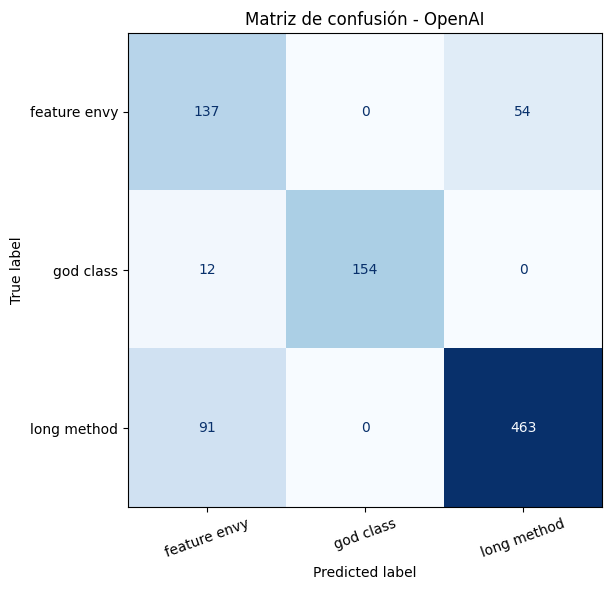

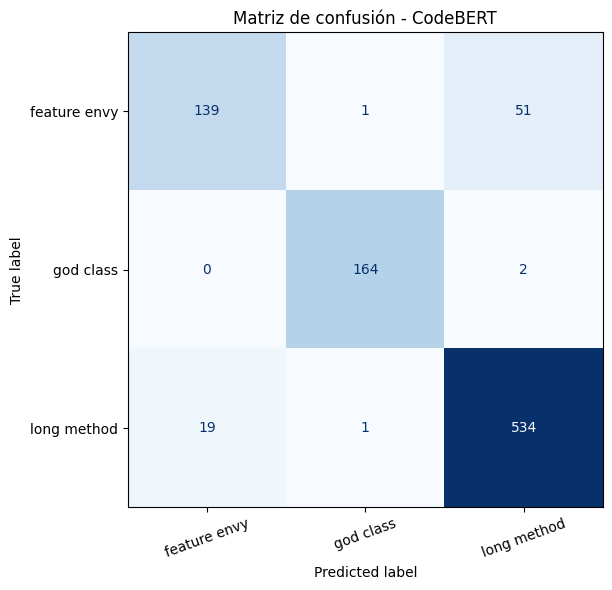

In [105]:
results_models = {
    "OpenAI": res_openai,
    "CodeBERT": res_codebert
}

plot_confusion_matrix_per_model(results_models, normalize=False)
# plot_confusion_matrix_per_model(results_models, normalize=True)

# PCA y TSNE

Columnas OpenAI: ['username', 'code', 'is_smell', 'smell', 'clean_code', 'embedding']
Columnas CodeBERT: ['username', 'code', 'is_smell', 'smell', 'clean_code', 'embedding']


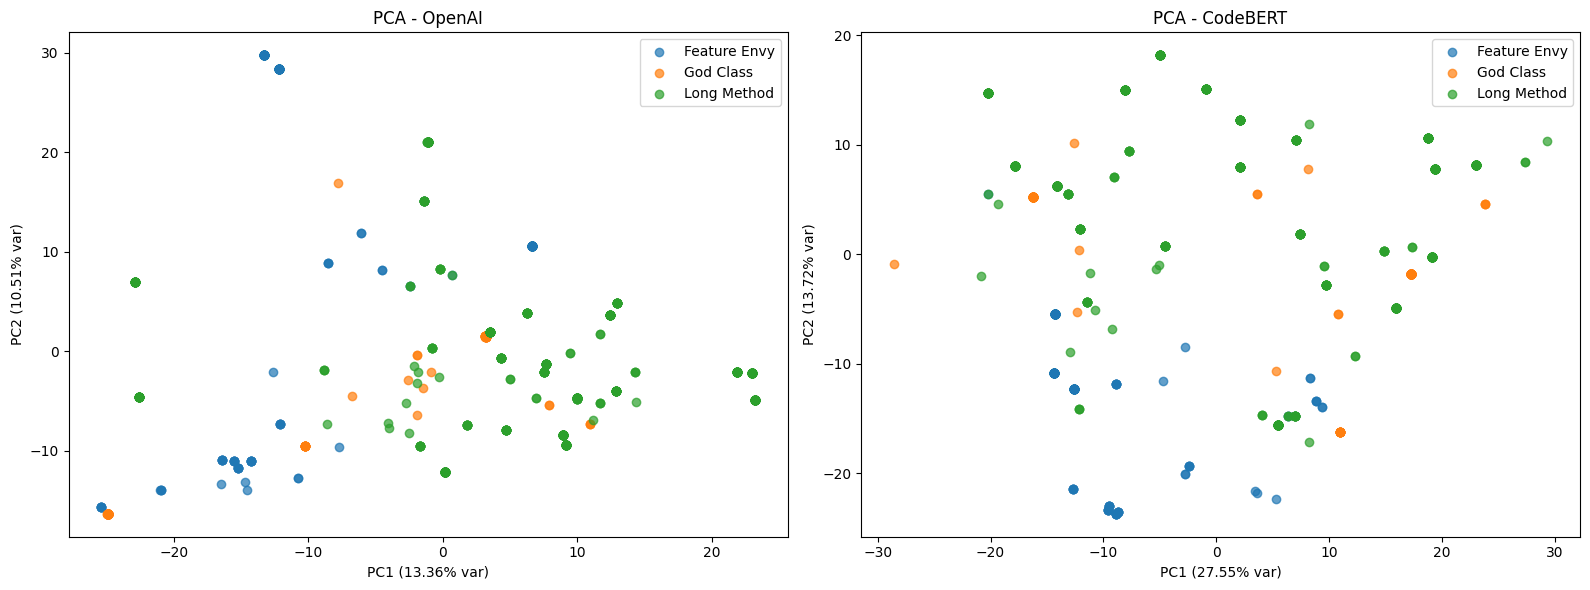

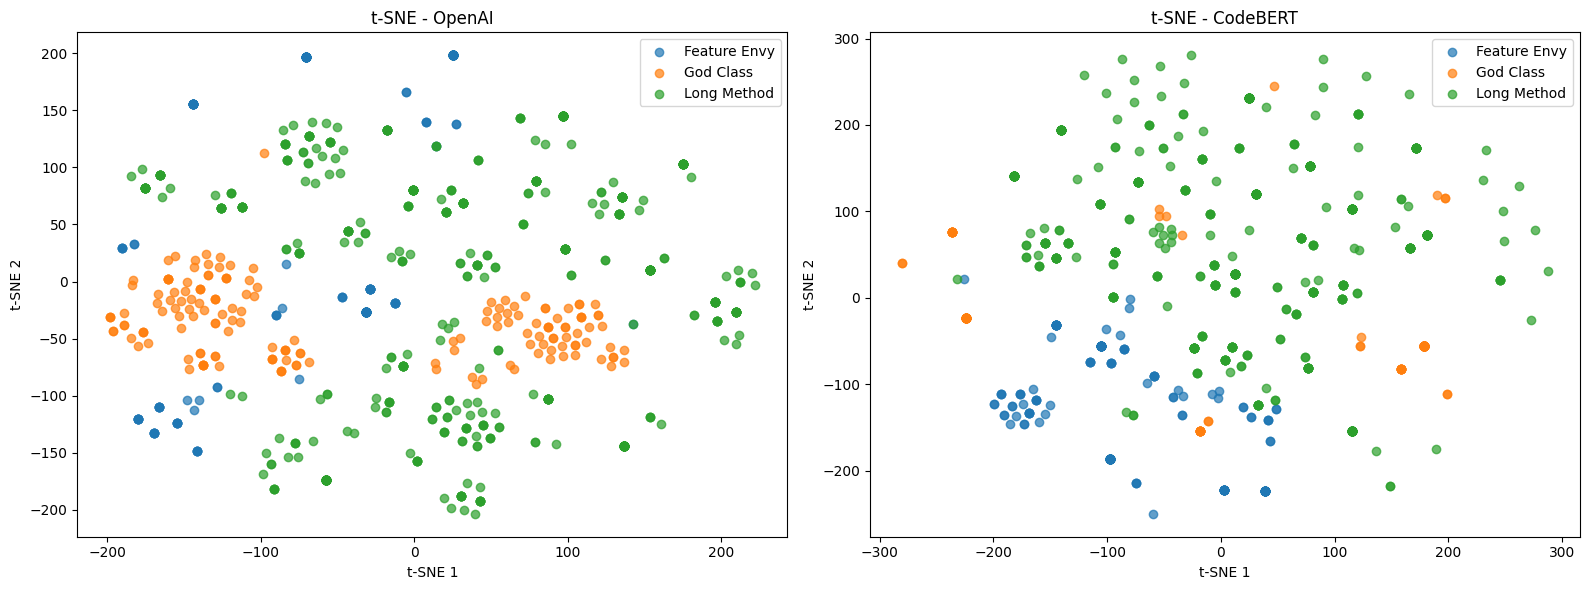

In [106]:
import pickle
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

path_openai = "dataset_smells_embeddings_openai.pkl"
path_codebert = "dataset_smells_embeddings_codebert.pkl"

with open(path_openai, "rb") as f:
    df_openai = pickle.load(f)

with open(path_codebert, "rb") as f:
    df_codebert = pickle.load(f)

if isinstance(df_openai, dict):
    df_openai = pd.DataFrame(df_openai)

if isinstance(df_codebert, dict):
    df_codebert = pd.DataFrame(df_codebert)

print("Columnas OpenAI:", df_openai.columns.tolist())
print("Columnas CodeBERT:", df_codebert.columns.tolist())

label_col = "smell"
embedding_col_openai = "embedding"
embedding_col_codebert = "embedding"

def get_xy(df, emb_col, label_col):
    df = df[[emb_col, label_col]].dropna().copy()
    X = np.vstack(df[emb_col].apply(lambda x: np.array(x)).values)
    y = df[label_col].astype(str).values
    X = StandardScaler().fit_transform(X)
    return X, y

def plot_2d(ax, X2d, y, title, xlabel, ylabel):
    for cls in np.unique(y):
        idx = (y == cls)
        ax.scatter(X2d[idx, 0], X2d[idx, 1], alpha=0.7, label=cls)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()

Xo, yo = get_xy(df_openai, embedding_col_openai, label_col)
Xc, yc = get_xy(df_codebert, embedding_col_codebert, label_col)

# PCA
pca_o = PCA(n_components=2, random_state=42)
pca_c = PCA(n_components=2, random_state=42)
Xo_pca = pca_o.fit_transform(Xo)
Xc_pca = pca_c.fit_transform(Xc)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_2d(axes[0], Xo_pca, yo, "PCA - OpenAI",
        f"PC1 ({pca_o.explained_variance_ratio_[0]*100:.2f}% var)",
        f"PC2 ({pca_o.explained_variance_ratio_[1]*100:.2f}% var)")
plot_2d(axes[1], Xc_pca, yc, "PCA - CodeBERT",
        f"PC1 ({pca_c.explained_variance_ratio_[0]*100:.2f}% var)",
        f"PC2 ({pca_c.explained_variance_ratio_[1]*100:.2f}% var)")
plt.tight_layout()
plt.show()

# t-SNE
tsne_o = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=42)
tsne_c = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=42)

Xo_tsne = tsne_o.fit_transform(Xo)
Xc_tsne = tsne_c.fit_transform(Xc)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_2d(axes[0], Xo_tsne, yo, "t-SNE - OpenAI", "t-SNE 1", "t-SNE 2")
plot_2d(axes[1], Xc_tsne, yc, "t-SNE - CodeBERT", "t-SNE 1", "t-SNE 2")
plt.tight_layout()
plt.show()

## Varianza acumulada de PCA


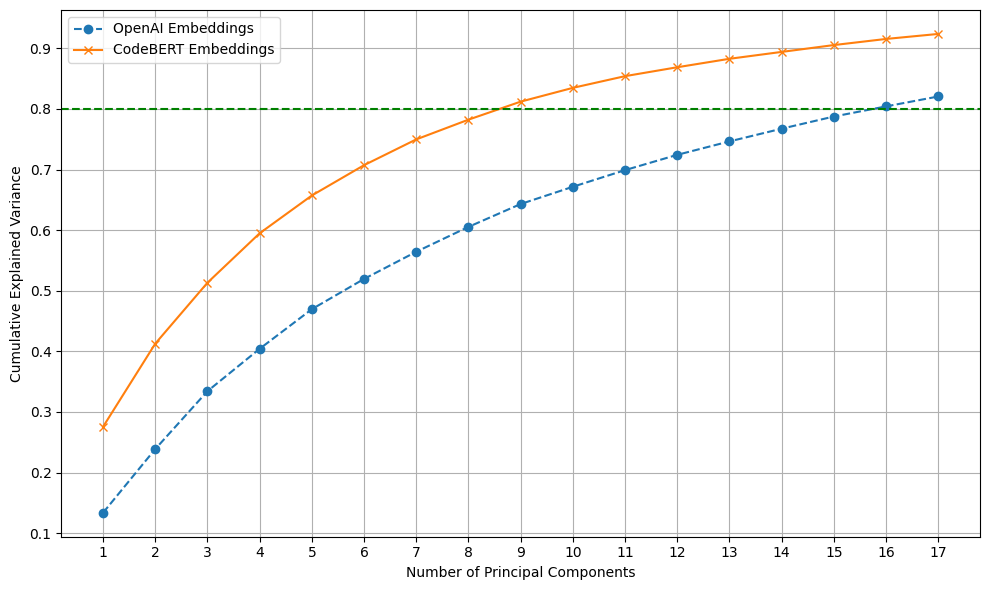

In [107]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pickle
import pandas as pd

path_openai = "dataset_smells_embeddings_openai.pkl"
path_codebert = "dataset_smells_embeddings_codebert.pkl"

with open(path_openai, "rb") as f:
    df_openai = pickle.load(f)

with open(path_codebert, "rb") as f:
    df_codebert = pickle.load(f)

if isinstance(df_openai, dict):
    df_openai = pd.DataFrame(df_openai)

if isinstance(df_codebert, dict):
    df_codebert = pd.DataFrame(df_codebert)

label_col = "smell"
embedding_col = "embedding"

def get_xy_for_pca(df, emb_col, label_col):
    df = df[[emb_col, label_col]].dropna().copy()
    X = np.vstack(df[emb_col].apply(lambda x: np.array(x)).values)
    X = StandardScaler().fit_transform(X)
    return X

Xo = get_xy_for_pca(df_openai, embedding_col, label_col)
Xc = get_xy_for_pca(df_codebert, embedding_col, label_col)

n_components_to_test = 17

# PCA para OpenAI
pca_o_full = PCA(n_components=min(n_components_to_test, Xo.shape[1]), random_state=42)
pca_o_full.fit(Xo)
cum_variance_o = np.cumsum(pca_o_full.explained_variance_ratio_)

# PCA para CodeBERT
pca_c_full = PCA(n_components=min(n_components_to_test, Xc.shape[1]), random_state=42)
pca_c_full.fit(Xc)
cum_variance_c = np.cumsum(pca_c_full.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_variance_o) + 1), cum_variance_o, marker='o', linestyle='--', label='OpenAI Embeddings')
plt.plot(range(1, len(cum_variance_c) + 1), cum_variance_c, marker='x', linestyle='-', label='CodeBERT Embeddings')
plt.axhline(y=0.8, color='g', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.legend()
plt.xticks(range(1, len(cum_variance_o) + 1))
plt.tight_layout()
plt.savefig('cumulative_variance_pca.png', dpi=300, bbox_inches='tight')
plt.show()